In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

In [5]:
# Read the data in
with open('speech.txt') as f:
    text = f.read().lower()
#text

In [6]:
# Read the dictionaries
with open('positive-words.txt', encoding='latin-1') as f: # latin-1 in case default doesn't work
    poswords = f.readlines() # 2,006 words

with open('negative-words.txt', encoding='latin-1') as f: # latin-1 in case default doesn't work
    negwords = f.readlines() # 4,783 words
#len(poswords)

In [7]:
# nltk.download('punkt_tab')
# nltk.download('stopwords')
tokens = word_tokenize(text)

In [8]:
#tokens

In [8]:
freq = Counter(tokens)

In [9]:
#freq

In [10]:
mylist = []
for i in range(1,4):
    mylist.append(i)
mylist

[1, 2, 3]

In [11]:
# get rid of stopwords like a, an, the... and punctiation like "! , ."
stop_words = set(stopwords.words('english'))

# for loop that checks if an element in the token list is a stopword or contains punctuation. If so, drops it
clean_token = []
for w in tokens:
    if w.isalpha() == True and w not in stop_words:
        clean_token.append(w)

In [12]:
#clean_token

In [13]:
freq = Counter(clean_token)
#freq

In [14]:
df = pd.DataFrame(freq.items(),columns=['word','count'])\
                            .sort_values('count',ascending=False)\
                            .reset_index(drop=True)
df

,word,count
0,america,29
1,families,26
2,people,25
3,new,24
4,family,24
...,...,...
1143,enforceable,1
1144,award,1
1145,write,1
1146,death,1


In [15]:
top_words = df.head(10)
top_words

,word,count
0,america,29
1,families,26
2,people,25
3,new,24
4,family,24
5,tonight,22
6,children,20
7,every,19
8,fight,18
9,one,18


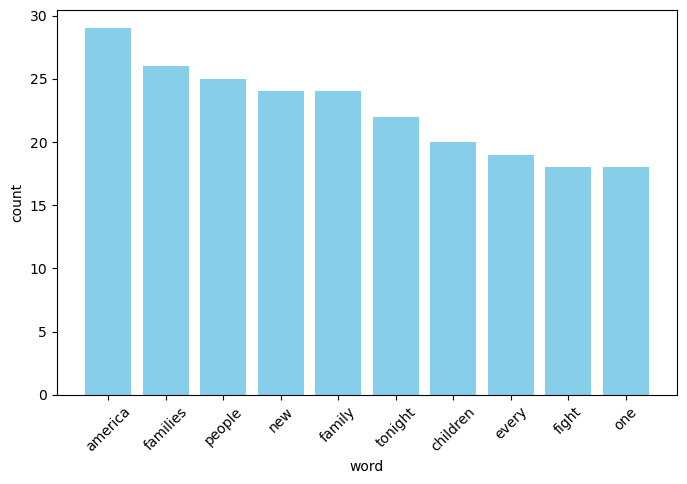

In [16]:
plt.figure(figsize=(8,5))
plt.bar(top_words['word'],top_words['count'],color='skyblue')
plt.xlabel('word')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

In [17]:
# words like families and family are considered to be different right now, but we should lemmatize all words and
# consider those with the same stem to be the same word
from nltk.stem import WordNetLemmatizer

#nltk.download('wordnet')
#nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer() # initate the lemmatizer

In [18]:
lemmatizer.lemmatize('families')

'family'

In [19]:
lemmatizer.lemmatize('children')

'child'

In [20]:
lemmas = []
for w in clean_token:
    word = lemmatizer.lemmatize(w)
    lemmas.append(word)

In [22]:
freq = Counter(lemmas)
               
df = pd.DataFrame(freq.items(),columns=['word','count'])\
                            .sort_values('count',ascending=False)\
                            .reset_index(drop=True)
df

,word,count
0,family,50
1,child,29
2,america,29
3,people,25
4,new,24
...,...,...
1065,enriches,1
1066,death,1
1067,made,1
1068,license,1


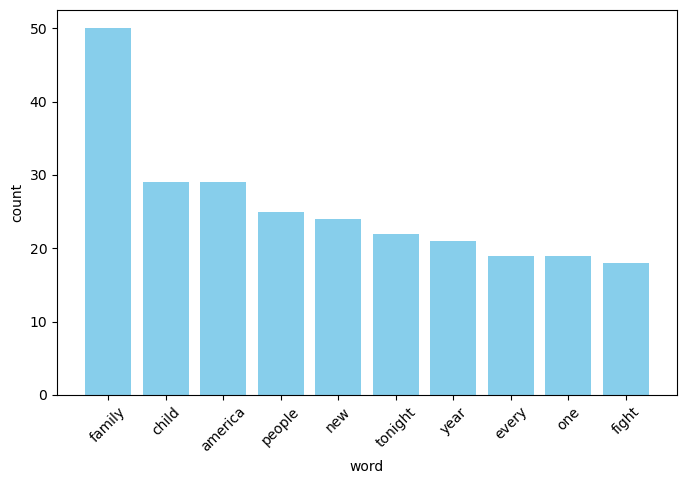

In [23]:
top_words = df.head(10)
top_words

plt.figure(figsize=(8,5))
plt.bar(top_words['word'],top_words['count'],color='skyblue')
plt.xlabel('word')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

In [24]:
# let's look positive and negative in Al Goore's speech

# stripping away the '\n' newline characters
pos_list=[]
for w in poswords:
    pos_list.append(w.strip())

neg_list=[]
for w in negwords:
    neg_list.append(w.strip())

In [25]:
# convert the dictionaries to pandas df
pos_df = pd.DataFrame(pos_list,columns=['word'])
pos_df['sentiment'] = 'positive'

neg_df = pd.DataFrame(neg_list,columns=['word'])
neg_df['sentiment'] = 'negative'


In [26]:
df

,word,count
0,family,50
1,child,29
2,america,29
3,people,25
4,new,24
...,...,...
1065,enriches,1
1066,death,1
1067,made,1
1068,license,1


In [27]:
pos_df

,word,sentiment
0,a+,positive
1,abound,positive
2,abounds,positive
3,abundance,positive
4,abundant,positive
...,...,...
2001,youthful,positive
2002,zeal,positive
2003,zenith,positive
2004,zest,positive


In [28]:
out_pos = pd.merge(df, pos_df, on=['word'])
out_neg = pd.merge(df, neg_df, on=['word'])

In [29]:
top_pos = out_pos.head(10)
top_neg = out_neg.head(10)

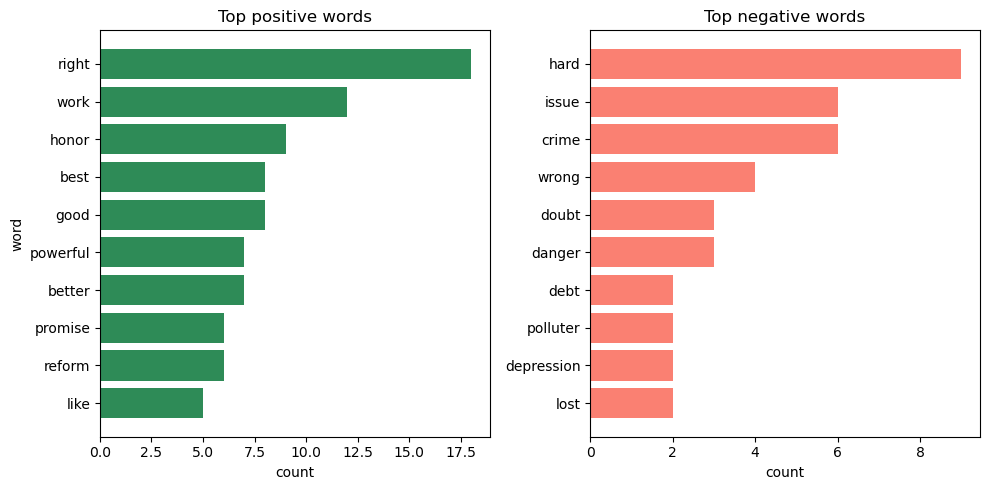

In [30]:
# two side by side barcharts
plt.figure(figsize=(10,5))

plt.subplot(1,2,1) # takes 3 arguments, first: number of graphs on y-axis, second: on the x axis, 
#third: which graph you are plotting
plt.barh(top_pos['word'],top_pos['count'],color='seagreen')
plt.title('Top positive words')
plt.xlabel('count')
plt.ylabel('word')
plt.gca().invert_yaxis() # inverts the y axis

plt.subplot(1,2,2)
plt.barh(top_neg['word'],top_neg['count'],color='salmon')
plt.title('Top negative words')
plt.xlabel('count')
#plt.ylabel('word')
plt.gca().invert_yaxis()


plt.tight_layout() # makes sure that axes are not touching each other
plt.show()

In [31]:
# freq of positive words that al gore used: num of positive words / number of total words
pos_freq = out_pos['count'].sum() / df['count'].sum()
neg_freq = out_neg['count'].sum() / df['count'].sum()

In [32]:
print(pos_freq)
print(neg_freq)

0.08754338603933667
0.043964519861164675


In [33]:
# on average, Al Gore used two times more positive words in relative to neg words on this speech

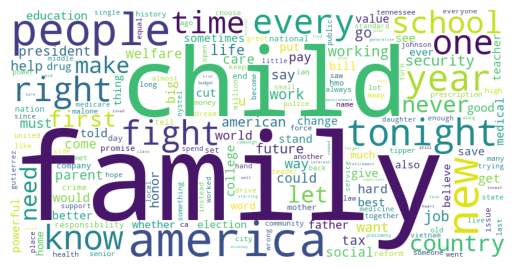

In [34]:
#! pip install wordcloud
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)

plt.imshow(wc)
plt.axis('off')

plt.show()